In [ ]:
!pip install librosa


In [ ]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

print("librosa version:", librosa.__version__)

librosa version: 0.11.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#audio_filename = '/content/drive/MyDrive/Capstone/Audio/G, D, F, C.m4a'
audio_filename = '/content/drive/MyDrive/Capstone/Audio/00_Funk1-97-C_comp.wav'


import os
if os.path.exists(audio_filename):
    print(f"Found: {audio_filename}")
else:
    print(f"NOT found: {audio_filename}")

ValueError: mount failed

In [ ]:
def detect_key_with_confidence(chroma_avg, low_confidence_threshold=0.05):
    """Detect key and return both result and confidence assessment."""
    ranked = detect_key(chroma_avg)
    top_key, top_score = ranked[0]
    second_key, second_score = ranked[1]
    gap = top_score - second_score

    if gap < low_confidence_threshold:
        confidence = "low"
        note = f"Top guess {top_key} vs. {second_key} are nearly tied — treat as uncertain"
    elif gap < 0.10:
        confidence = "medium"
        note = f"Reasonable confidence in {top_key}"
    else:
        confidence = "high"
        note = f"High confidence in {top_key}"

    return {
        "key": top_key,
        "confidence": confidence,
        "gap": gap,
        "note": note,
        "ranked": ranked[:5]
    }

result = detect_key_with_confidence(chroma_avg)
print(f"Detected key: {result['key']}")
print(f"Confidence:   {result['confidence']} (gap={result['gap']:.3f})")
print(f"Note:         {result['note']}")

Detected key: G major
Confidence:   high (gap=0.142)
Note:         High confidence in G major


In [ ]:
# Load audio (y is the waveform, sr is the sample rate)
y, sr = librosa.load(audio_filename, sr=None)
print(f"Loaded {len(y)/sr:.1f} seconds of audio at {sr} Hz")

# Compute chromagram — energy at each pitch class over time
chroma = librosa.feature.chroma_cqt(y=y, sr=sr)
print(f"Chromagram shape: {chroma.shape}")
print(f"  (12 pitch classes, {chroma.shape[1]} time frames)")

Loaded 22.3 seconds of audio at 44100 Hz
Chromagram shape: (12, 1923)
  (12 pitch classes, 1923 time frames)


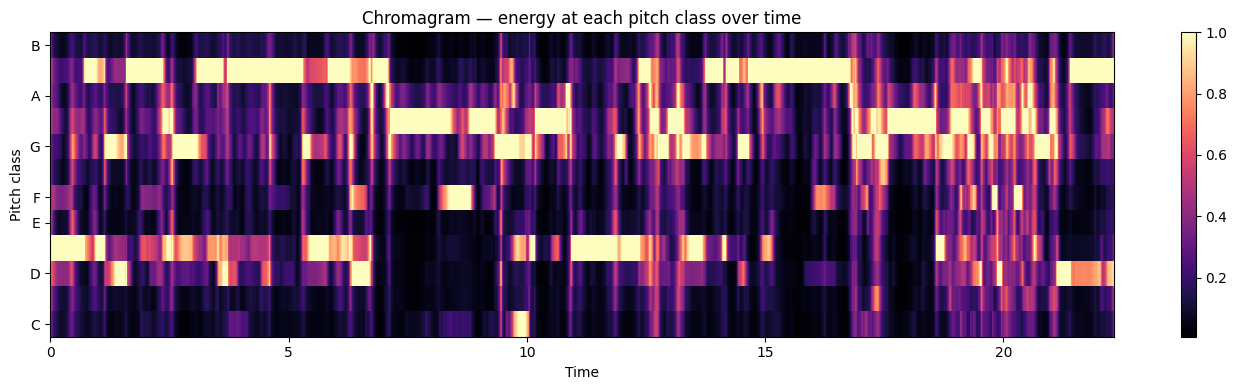

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
img = librosa.display.specshow(chroma, y_axis='chroma', x_axis='time',
                                sr=sr, cmap='magma', ax=ax)
plt.colorbar(img, ax=ax)
ax.set_title('Chromagram — energy at each pitch class over time')
plt.tight_layout()
plt.show()

In [ ]:
# Average chromagram across time → single 12-element vector
chroma_avg = np.mean(chroma, axis=1)

# Map to pitch class names
pitch_classes = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

print("Average energy per pitch class:")
for i, pc in enumerate(pitch_classes):
    bar = '█' * int(chroma_avg[i] * 40)  # crude bar chart
    print(f"  {pc:2s}  {chroma_avg[i]:.3f}  {bar}")

Average energy per pitch class:
  C   0.139  █████
  C#  0.145  █████
  D   0.304  ████████████
  D#  0.442  █████████████████
  E   0.151  ██████
  F   0.229  █████████
  F#  0.202  ████████
  G   0.504  ████████████████████
  G#  0.506  ████████████████████
  A   0.324  ████████████
  A#  0.577  ███████████████████████
  B   0.142  █████


In [ ]:
# Krumhansl-Schmuckler key profiles
# These are empirically-derived templates of how often each pitch
# appears in major and minor keys (from listener experiments).
major_profile = np.array([6.35, 2.23, 3.48, 2.33, 4.38, 4.09,
                           2.52, 5.19, 2.39, 3.66, 2.29, 2.88])
minor_profile = np.array([6.33, 2.68, 3.52, 5.38, 2.60, 3.53,
                           2.54, 4.75, 3.98, 2.69, 3.34, 3.17])

def detect_key(chroma_avg):
    """Detect the key by correlating the song's pitch profile against
    all 24 possible key templates (12 major + 12 minor)."""

    correlations = {}

    for tonic in range(12):
        # Rotate the major template to put the tonic at position 0
        major_template = np.roll(major_profile, tonic)
        minor_template = np.roll(minor_profile, tonic)

        # Correlate (higher = better match)
        major_corr = np.corrcoef(chroma_avg, major_template)[0, 1]
        minor_corr = np.corrcoef(chroma_avg, minor_template)[0, 1]

        correlations[f"{pitch_classes[tonic]} major"] = major_corr
        correlations[f"{pitch_classes[tonic]} minor"] = minor_corr

    # Sort by correlation strength
    ranked = sorted(correlations.items(), key=lambda x: x[1], reverse=True)
    return ranked

ranked_keys = detect_key(chroma_avg)

print("Top 5 most likely keys:")
for i, (key, score) in enumerate(ranked_keys[:5]):
    bar = '█' * int(score * 30)
    print(f"  {i+1}. {key:12s}  correlation={score:.3f}  {bar}")

print(f"\nMost likely key: {ranked_keys[0][0]}")
print(f"Confidence (top-2 gap): {ranked_keys[0][1] - ranked_keys[1][1]:.3f}")

Top 5 most likely keys:
  1. D# major      correlation=0.757  ██████████████████████
  2. G minor       correlation=0.665  ███████████████████
  3. A# major      correlation=0.492  ██████████████
  4. G# major      correlation=0.374  ███████████
  5. D# minor      correlation=0.253  ███████

Most likely key: D# major
Confidence (top-2 gap): 0.091
